In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Junayed\nyc-311-resolution-time-analysis\data\clean\311_jan_week1_clean.csv")

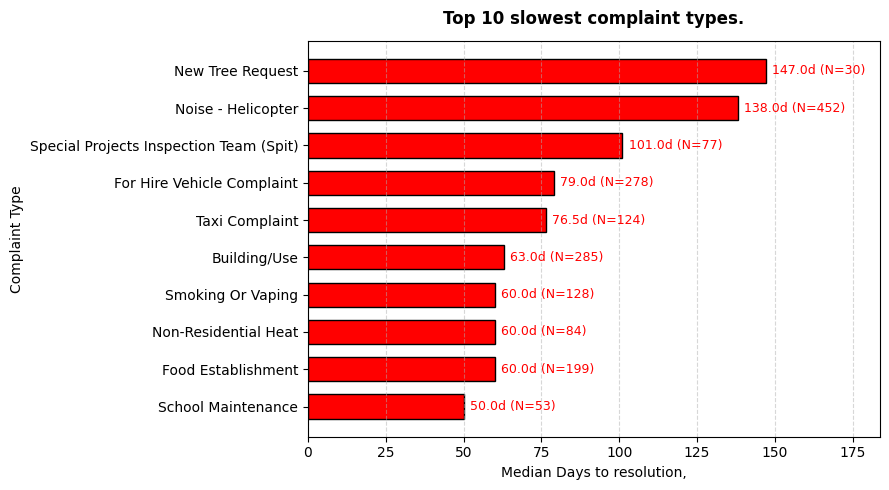

In [8]:
complaint_stats = df.groupby("Complaint_Type")["Resolution_Days"].agg(
    Median = "median",
    Ticket_Count = "count"
)

top_10_slowest = (
    complaint_stats[complaint_stats["Ticket_Count"] >=20]
    .sort_values(by="Median", ascending=True)
).tail(10)

# top_10_slowest - run for to check the dataset

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.barh(
    top_10_slowest.index,
    top_10_slowest["Median"],
    color="red",
    edgecolor="black",
    height=0.65
)

for bar, (name, row) in zip(bars, top_10_slowest.iterrows()):
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Median']:.1f}d (N={int(row['Ticket_Count'])})",
        va="center",
        fontsize=9,
        color="red"
    )

ax.set_title(
    "Top 10 slowest complaint types.",
    fontsize= 12,
    fontweight = "bold",
    pad = 12
)

ax.set_xlabel(
    "Median Days to resolution,",
    fontsize = 10
)

ax.set_ylabel(
    "Complaint Type",
    fontsize = 10
)

ax.set_xlim(
    0, top_10_slowest["Median"].max() *1.25
)

ax.grid(axis="x", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()